Loading the unhealthy dataset

In [6]:
import cv2
import os
from PIL import Image
import time
import matplotlib.pyplot as plt
import numpy as np

Loaded 250 images.


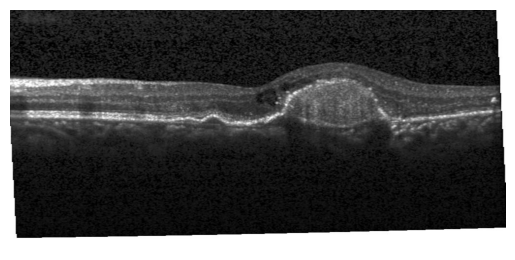

In [27]:

folder_path = "Data/CellData/OCT/test/CNV"

# Get all image file names
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpeg', '.jpeg'))]

# Load them
images_unhealthy = []
for file in image_files:
    img_path = os.path.join(folder_path, file)
    img = Image.open(img_path)
    images_unhealthy.append(img)

print(f"Loaded {len(images_unhealthy)} images.")

plt.imshow(images_unhealthy[5], cmap='gray')
plt.axis('off')

plt.show()


Loading the healthy dataset

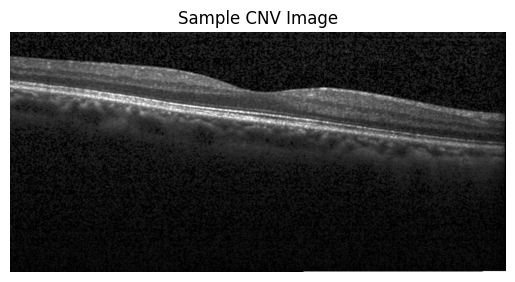

In [21]:

# Path to your folder
folder_path = "Data/CellData/OCT/test/Normal"

# Get all image file names
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpeg', '.jpeg'))]

# Load them
images_healthy = []
for file in image_files:
    img_path = os.path.join(folder_path, file)
    img = Image.open(img_path)
    images_healthy.append(img)

plt.imshow(images_healthy[3], cmap='gray')
plt.axis('off')
plt.title('Sample CNV Image')
plt.show()


Remove borders

Updated 250 unhealthy and 250 healthy images (white borders set to black).


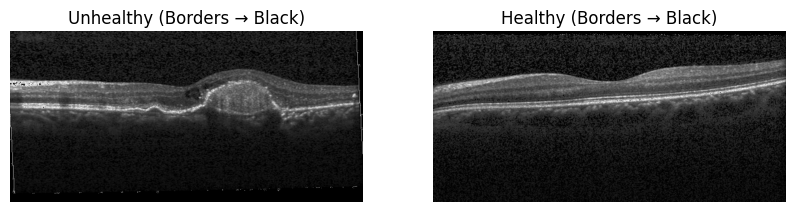

In [53]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Function to replace white border pixels with black
def remove_white_borders(img, threshold=250):
    gray = img.convert("L")
    arr = np.array(gray)
    mask = arr >= threshold
    arr[mask] = 0
    return Image.fromarray(arr)

# 🔄 Modify the existing arrays directly
for i in range(len(images_unhealthy)):
    images_unhealthy[i] = remove_white_borders(images_unhealthy[i])

for i in range(len(images_healthy)):
    images_healthy[i] = remove_white_borders(images_healthy[i])

print(f"Updated {len(images_unhealthy)} unhealthy and {len(images_healthy)} healthy images (white borders set to black).")

# Show before and after for one example
idx = 5
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy[idx], cmap='gray')
plt.axis('off')
plt.title('Unhealthy (Borders → Black)')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy[idx], cmap='gray')
plt.axis('off')
plt.title('Healthy (Borders → Black)')

plt.show()


Enhanced 250 unhealthy images and 250 healthy images.


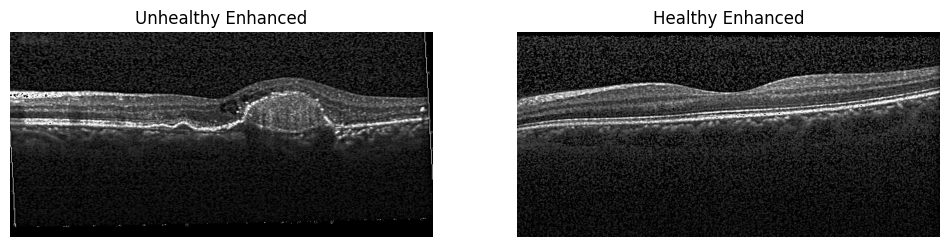

In [54]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def enhance_low_high(img, blur_kernel=(27, 27), highpass_weight=1.0):
    """
    Apply Gaussian low-pass filter + high-pass enhancement.
    Returns a grayscale PIL image.
    """
    # Convert to grayscale and float32
    gray = img.convert("L")
    arr = np.array(gray).astype(np.float32)
    
    # Low-pass (Gaussian blur)
    blurred = cv2.GaussianBlur(arr, blur_kernel, 0)
    
    # High-pass
    highpass = arr - blurred
    
    # Combine (original + weighted high-pass)
    sharpened = cv2.addWeighted(arr, 1.0, highpass, highpass_weight, 0)
    
    # Clip to valid range
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    return Image.fromarray(sharpened)

# 🧠 Apply to all images
images_unhealthy_enhanced = [enhance_low_high(img) for img in images_unhealthy]
images_healthy_enhanced = [enhance_low_high(img) for img in images_healthy]

print(f"Enhanced {len(images_unhealthy_enhanced)} unhealthy images and {len(images_healthy_enhanced)} healthy images.")

# 🔍 Show one example from each
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(images_unhealthy_enhanced[5], cmap='gray')
plt.axis('off')
plt.title('Unhealthy Enhanced')

plt.subplot(1, 2, 2)
plt.imshow(images_healthy_enhanced[5], cmap='gray')
plt.axis('off')
plt.title('Healthy Enhanced')

plt.show()
